Umbralizacion binaria y binaria inversa

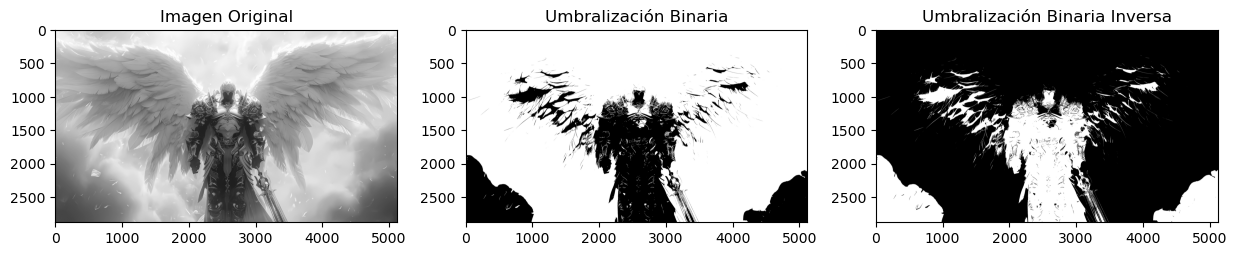

In [13]:
import cv2
import matplotlib.pyplot as plt

imagen = cv2.imread('Fond.jpg',0)

# umbralización binaria
_, umbral_binario = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY)

# umbralización binaria inversa
_, umbral_binario_in = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(15, 8))
plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap='gray') 
plt.title('Imagen Original')


plt.subplot(1, 3, 2)
plt.imshow(umbral_binario, cmap='gray') 
plt.title('Umbralización Binaria')


plt.subplot(1, 3, 3)
plt.imshow(umbral_binario_in, cmap='gray') 
plt.title('Umbralización Binaria Inversa')

plt.show()


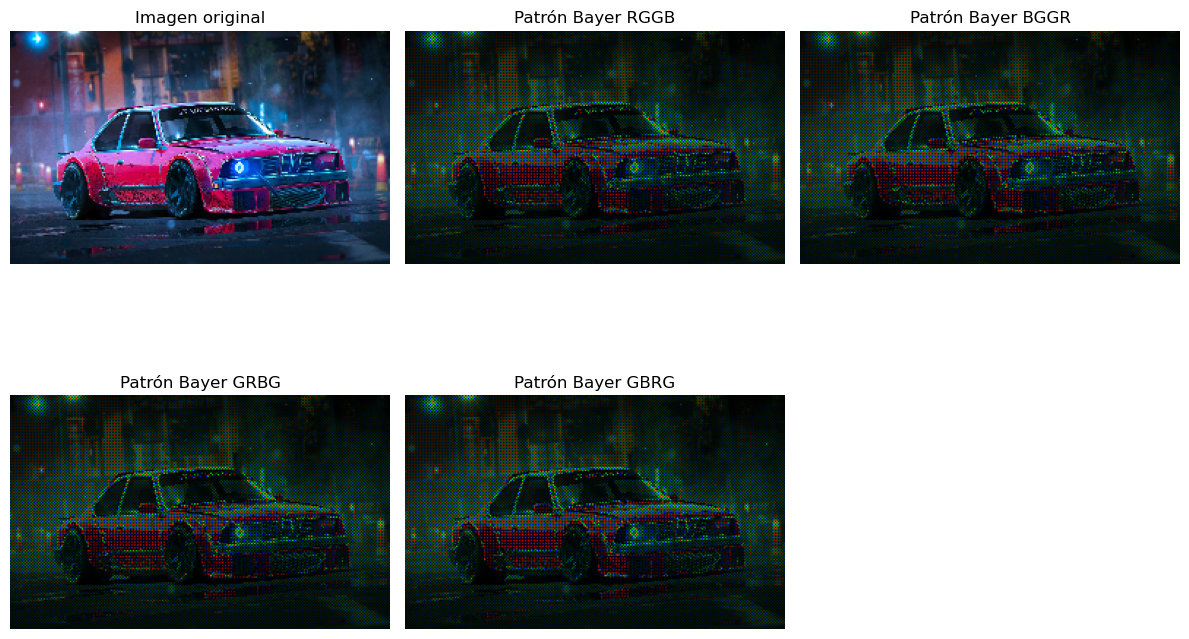

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen
img = cv2.imread("BMW_635.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


img = cv2.resize(img,(260,160))

h,w,_ = img.shape

def aplicar_bayer(img,patron):

    resultado = np.zeros_like(img)

    if patron=="RGGB":

        resultado[0::2,0::2,0] = img[0::2,0::2,0]  
        resultado[0::2,1::2,1] = img[0::2,1::2,1]  
        resultado[1::2,0::2,1] = img[1::2,0::2,1]  
        resultado[1::2,1::2,2] = img[1::2,1::2,2]  

    if patron=="BGGR":

        resultado[0::2,0::2,2] = img[0::2,0::2,2]  
        resultado[0::2,1::2,1] = img[0::2,1::2,1]  
        resultado[1::2,0::2,1] = img[1::2,0::2,1]  
        resultado[1::2,1::2,0] = img[1::2,1::2,0]  

    if patron=="GRBG":

        resultado[0::2,0::2,1] = img[0::2,0::2,1]  
        resultado[0::2,1::2,0] = img[0::2,1::2,0]  
        resultado[1::2,0::2,2] = img[1::2,0::2,2]  
        resultado[1::2,1::2,1] = img[1::2,1::2,1]  

    if patron=="GBRG":

        resultado[0::2,0::2,1] = img[0::2,0::2,1]  
        resultado[0::2,1::2,2] = img[0::2,1::2,2]  
        resultado[1::2,0::2,0] = img[1::2,0::2,0]  
        resultado[1::2,1::2,1] = img[1::2,1::2,1]  

    return resultado


patrones = ["RGGB","BGGR","GRBG","GBRG"]

plt.figure(figsize=(12,8))


plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Imagen original")
plt.axis("off")

for i,p in enumerate(patrones):

    img_bayer = aplicar_bayer(img,p)

    
    img_bayer = cv2.resize(img_bayer,None,fx=3,fy=3,interpolation=cv2.INTER_NEAREST)

    plt.subplot(2,3,i+2)
    plt.imshow(img_bayer)
    plt.title("Patrón Bayer "+p)
    plt.axis("off")

plt.tight_layout()
plt.show()

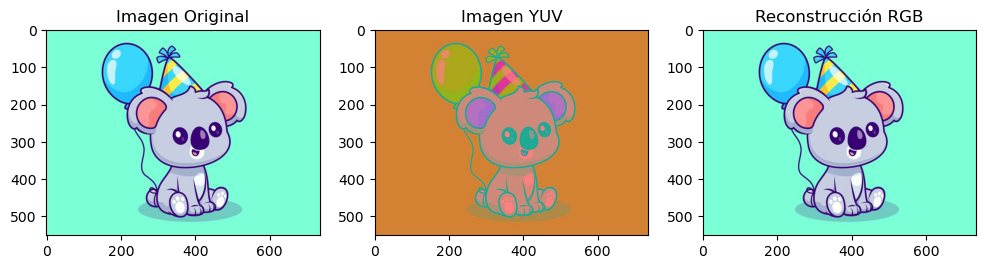

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Leer imagen original
img = cv2.imread("imgKoala.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convertir a YUV
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

# Convertir nuevamente a RGB
img_rgb_recon = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)


plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Imagen Original")

plt.subplot(1,3,2)
plt.imshow(img_yuv)
plt.title("Imagen YUV")

plt.subplot(1,3,3)
plt.imshow(img_rgb_recon)
plt.title("Reconstrucción RGB")

plt.show()